In [1]:
#%matplotlib inline
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Set random seed for reproducibility
#manualSeed = 999
#manualSeed = random.randint(1, 10000) # use if you want new results
#print("Random Seed: ", manualSeed)
#random.seed(manualSeed)
#torch.manual_seed(manualSeed)
#torch.use_deterministic_algorithms(True) # Needed for reproducible results

# Prepare GPU

In [2]:
# Decide which device we want to run on
device = torch.device("cuda:0" if (torch.cuda.is_available()) else "cpu")
print(device)

cuda:0


# Import Generator

In [3]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, nz=128, ngf=64, nc=3):
        super().__init__()

        self.main = nn.Sequential(
            # 1x1 → 5x16
            nn.ConvTranspose2d(nz, ngf*16, kernel_size=(5,16), stride=1, padding=0, bias=False),
            nn.BatchNorm2d(ngf*16),
            nn.ReLU(True),

            # 5x16 → 10x32
            nn.ConvTranspose2d(ngf*16, ngf*8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(True),

            # 10x32 → 20x64
            nn.ConvTranspose2d(ngf*8, ngf*4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            # 20x64 → 40x128
            nn.ConvTranspose2d(ngf*4, ngf*2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            # 40x128 → 40x256 (double width only)
            nn.ConvTranspose2d(ngf*2, ngf, kernel_size=(3,4), stride=(1,2), padding=(1,1), bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            # final: 40×256 → output RGB
            nn.ConvTranspose2d(ngf, nc, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.main(z)

In [4]:
netG = Generator()
netG.load_state_dict(torch.load("generator.pth", map_location=device))
netG.eval()

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(128, 1024, kernel_size=(5, 16), stride=(1, 1), bias=False)
    (1): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(1024, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(128, 64, kernel_size=(3, 4), stride=(1, 2), padding=(1, 1), bias=False)
    (13): Batch

# Generate Image(s)

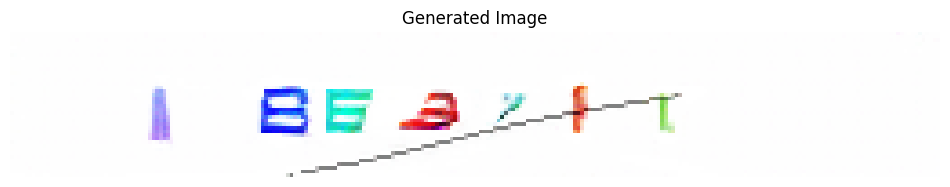

In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np

with torch.no_grad():
    noise = torch.randn(16, 128, 1, 1)  # example batch of latent vectors
    fake_images = netG(noise)

# Take the first image in the batch
img = fake_images[0].cpu().numpy()  # shape: [3, 40, 256]

# Convert from [C,H,W] to [H,W,C] for matplotlib
img = np.transpose(img, (1, 2, 0))

# Scale from [-1,1] to [0,1] (since generator likely uses Tanh)
img = (img + 1) / 2

# Display
plt.figure(figsize=(12, 2))
plt.axis('off')
plt.title("Generated Image")
plt.imshow(img)
plt.show()